File to visualize the label and graph

In [209]:
from pathlib import Path
import nibabel as nib
import json
import matplotlib.pyplot as plt
from data.visualizations import visualize_3d_matrices
import pprint
import numpy as np

In [210]:
label_graph_folder = Path("label_graph/")
graph_fp = label_graph_folder / "00328c.graph.json"
label_fp = label_graph_folder / "00328c.label.nii.gz"

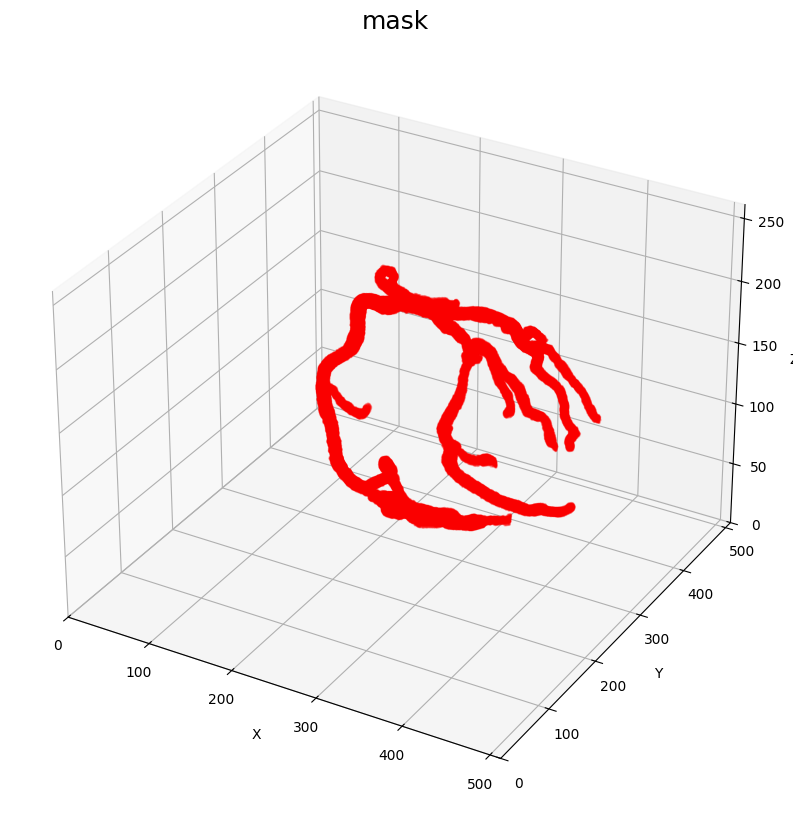

In [211]:
# Let's start with the mask
mask = nib.load(label_fp)
mask_matrice = mask.get_fdata()

visualize_3d_matrices(matrices=[mask_matrice], titles=["mask"])

In [212]:
# now the graph
with open(graph_fp, "r") as file:
    data = json.load(file)

pprint.pp(data["edges"])

[{'length': 45.555038631672225,
  'skeletons': [[-3.9306640625, 149.6103515625, -255.54998779296875],
                [-6.126192249041056, 149.9599770429464, -258.04998779296875],
                [-8.14768095468244, 151.59885282968244, -259.00876075463884],
                [-10.283266892278974, 153.416079392279, -259.6384502387676],
                [-12.042070778520191, 155.4932426535202, -260.30305196216773],
                [-13.879228167310293, 157.270957967176, -261.04998779296875],
                [-15.881907363569796, 158.8194203219174, -262.0133105071458],
                [-18.09720079118183, 159.92551012955806, -263.04998779296875],
                [-20.317997051971894, 160.76020554989023, -263.7871488071087],
                [-21.973209699622256, 162.24078782462226, -264.54998779296875],
                [-23.522207272858633, 163.79071705338518, -265.2775211090338],
                [-24.75324306631261, 165.97589931631262, -266.25293395846586],
                [-25.2983951599041

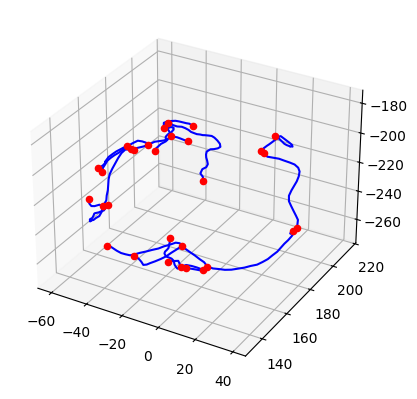

In [213]:
# Plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for node in data["nodes"]:
    [x, y, z] = node["pos"]
    ax.scatter(x, y, z, c="r")

for edge in data["edges"]:
    # length = edge["length"]
    # source = edge["source"]
    # target = edge["target"]

    skeletons = edge["skeletons"]
    xs, ys, zs = zip(*skeletons) # this is all we plot
    ax.plot(xs, ys, zs, c="b")

# get the np array from the plot
plt.show()

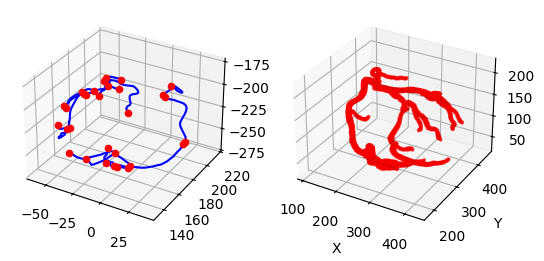

In [214]:
# let's plot them next to each other
def plot_graph_and_matrice(graph_data, mask_matrice):
    fig = plt.figure()
    ax1 = fig.add_subplot(121, projection='3d')
    ax2 = fig.add_subplot(122, projection='3d')

    for node in graph_data["nodes"]:
        [x, y, z] = node["pos"]
        ax1.scatter(x, y, z, c="r")

    for edge in graph_data["edges"]:
        # length = edge["length"]
        # source = edge["source"]
        # target = edge["target"]

        skeletons = edge.get("skeletons")

        if skeletons is None:
            # print("Edge without skeletons")
            # we still plot the connection between the nodes
            source = edge["source"]
            target = edge["target"]
            source_pos = graph_data["nodes"][source]["pos"]
            target_pos = graph_data["nodes"][target]["pos"]
            xs, ys, zs = zip(source_pos, target_pos)
            ax1.plot(xs, ys, zs, c="b")
        else:
            xs, ys, zs = zip(*skeletons) # this is all we plot
            ax1.plot(xs, ys, zs, c="b")

    x, y, z = np.where(mask_matrice == 1)
    ax2.scatter(x, y, z, c='red', marker='o', s=0.005, alpha=0.2)

    # Set labels even if we don't show them
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    plt.show()

plot_graph_and_matrice(graph_data=data, mask_matrice=mask_matrice)

Okay this is more complex than it looks like. We need to analyze this.

In [215]:
# We know that the graph is in the same space as the mask
# however they define the space differently. Rotation, and distances are different.

# Let's try to align them

# let's get the the header data from the nib file
mask_header = mask.header
print(mask_header)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b''
dim_info        : 0
dim             : [  3 512 512 261   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float64
bitpix          : 64
slice_start     : 0
pixdim          : [-1.          0.31835938  0.31835938  0.5         1.          1.
  1.          1.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 0
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : unknown
sform_code      : aligned
quatern_b       : 0.0
quatern_c       : 1.0
quatern_d       : 0.0
qoffset_x       : 75.34082
qoffset_y       : 74.15918
qo

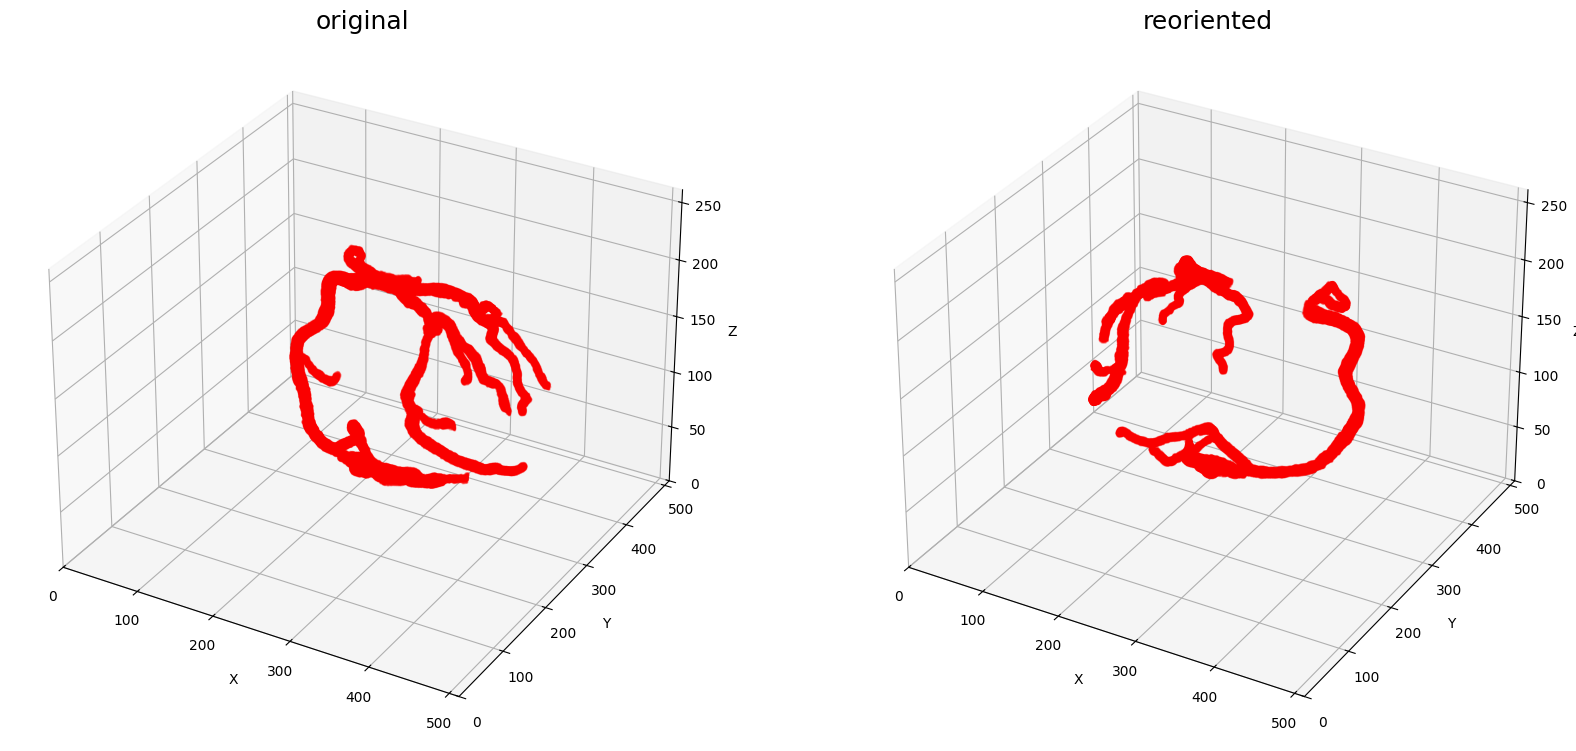

In [216]:
# we need a function that calculates distances between two points in the mask label
# This function has multiple steps: 1. Reorientation
ras_mask = nib.as_closest_canonical(mask)
ras_mask_matrice = ras_mask.get_fdata()

visualize_3d_matrices(matrices=[mask_matrice, ras_mask_matrice], titles=["original", "reoriented"])


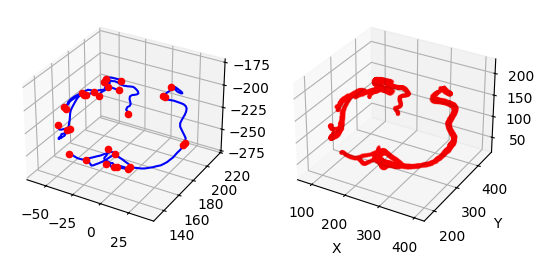

In [217]:
plot_graph_and_matrice(data, ras_mask_matrice)

In [218]:
print(f"non transformed affine mask: {mask.affine}")
print(f"rotated affine mask: {ras_mask.affine}")

non transformed affine mask: [[  -0.31835938    0.            0.           75.34082031]
 [  -0.            0.31835938    0.           74.15917969]
 [   0.           -0.            0.5        -285.54998779]
 [   0.            0.            0.            1.        ]]
rotated affine mask: [[   0.31835938    0.            0.          -87.34082031]
 [   0.            0.31835938    0.           74.15917969]
 [   0.            0.            0.5        -285.54998779]
 [   0.            0.            0.            1.        ]]


[262. 237.  60.]


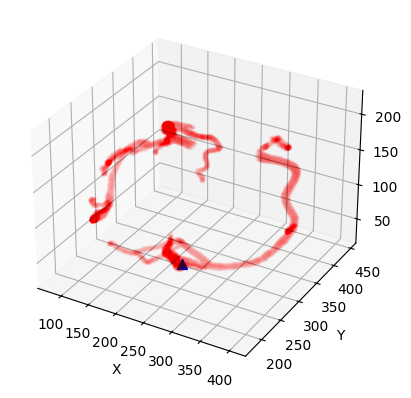

In [219]:
# okay seems like we now know how to transform it, we use the affine matrix. 
# This is computationally heavy, let's first do a sanity test. Let's take a point from the graph and plot it in the mask.

# x, y, z = [-3.9306640625, 149.6103515625, -255.54998779296875]
node_coords = np.array([-3.9306640625, 149.6103515625, -255.54998779296875, 1])
voxel_coords = np.linalg.inv(ras_mask.affine) @ node_coords
voxel_coords = voxel_coords[:3]
print(voxel_coords)

x, y, z = np.where(ras_mask_matrice == 1)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, c='red', marker='o', s=0.005, alpha=0.05)
ax.scatter(voxel_coords[0], voxel_coords[1], voxel_coords[2], c='blue', marker='^', s=50, alpha=1.0)

# Set labels even if we don't show them
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

We now know how to align the data from the voxels to RTS coordinates. Next step is actually getting a graph.

In [220]:
from skimage.morphology import skeletonize

skeleton = skeletonize(ras_mask_matrice)

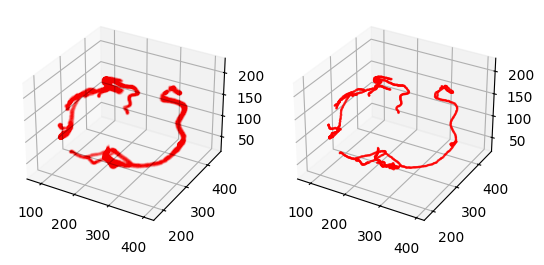

In [221]:
# let's visualize the skeleton
fig = plt.figure()

ax1 = fig.add_subplot(121, projection='3d')

x, y, z = np.where(ras_mask_matrice == 1)
ax1.scatter(x, y, z, c='red', marker='o', s=0.005, alpha=0.05)

ax2 = fig.add_subplot(122, projection='3d')

x, y, z = np.where(skeleton == 1)
ax2.scatter(x, y, z, c='red', marker='o', s=0.5, alpha=0.5)

plt.show()

In [222]:
def plot_networkx_graph(graph_data, title):
    plt.figure()
    ax = plt.subplot(111, projection='3d')

    for node_id in graph_data.nodes:
        pos = graph_data.nodes[node_id]['pts'][0].tolist()
        ax.scatter(pos[0], pos[1], pos[2], c='r')
    
    for (s, e) in graph_data.edges():
        ps = graph_data[s][e]['pts']
        ax.plot(ps[:, 0], ps[:, 1], ps[:, 2], c='b')

    plt.title(title)
    plt.show()

Graph with 67 nodes and 77 edges


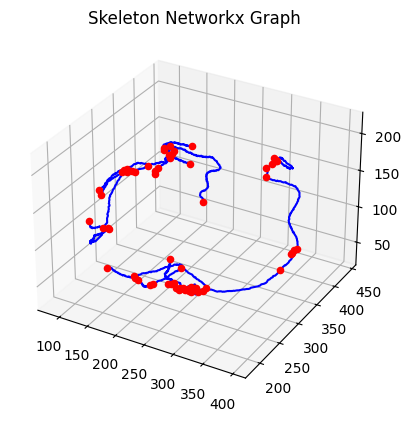

In [223]:
import sknw

snkw_graph = sknw.build_sknw(skeleton, multi=False, iso=False)
print(snkw_graph)

# let's plot the graph
plot_networkx_graph(snkw_graph, "Skeleton Networkx Graph")

In [224]:
pprint.pp(data)

{'directed': True,
 'multigraph': False,
 'graph': {'coordinateSystem': 'RAS'},
 'nodes': [{'pos': [-3.9306640625, 149.6103515625, -255.54998779296875],
            'is_root': False,
            'id': 1},
           {'pos': [39.3662109375, 178.5810546875, -235.54998779296875],
            'is_root': False,
            'id': 2},
           {'pos': [16.4443359375, 185.2666015625, -198.54998779296875],
            'is_root': True,
            'id': 4},
           {'pos': [-27.8076171875, 158.2060546875, -188.54998779296875],
            'is_root': False,
            'id': 5},
           {'pos': [5.3017578125, 153.7490234375, -257.54998779296875],
            'is_root': False,
            'id': 7},
           {'pos': [-38.6318359375, 157.2509765625, -192.54998779296875],
            'is_root': False,
            'id': 8},
           {'pos': [-3.9306640625, 150.5654296875, -242.04998779296875],
            'is_root': False,
            'id': 9},
           {'pos': [-35.4482421875, 180.49121

In [225]:
# https://networkx.org/documentation/stable/reference/readwrite/generated/networkx.readwrite.json_graph.node_link_graph.html#networkx.readwrite.json_graph.node_link_graph

In [226]:
import networkx as nx

# let#s convert it to json
snkw_json = nx.node_link_data(snkw_graph, edges="edges")
print(snkw_json.keys())
print(snkw_json["nodes"][0])



dict_keys(['directed', 'multigraph', 'graph', 'nodes', 'edges'])
{'pts': array([[ 84, 300,  71]], dtype=int16), 'o': array([ 84, 300,  71], dtype=uint16), 'id': 0}


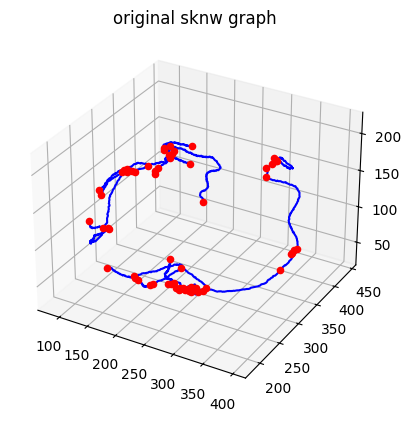

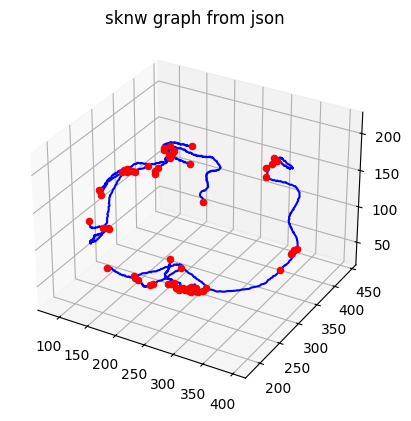

In [227]:
# okay cool this works.

# now we need is to make sure that the profs can load the networkx graph from the json file.
# let's create a graph from snkw_json
snkw_graph_from_json = nx.node_link_graph(snkw_json, directed=False, multigraph=False, edges="edges")

# let's plot it
plot_networkx_graph(snkw_graph, title="original sknw graph")
plot_networkx_graph(snkw_graph_from_json, title="sknw graph from json")

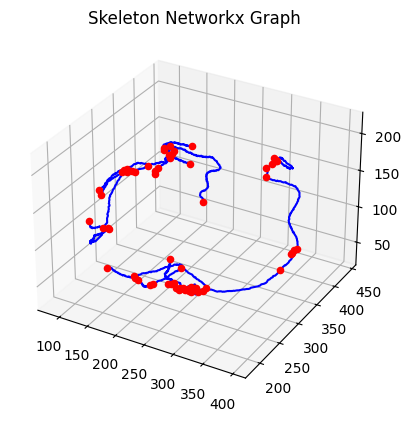

In [228]:
import nibabel as nib
from skimage.morphology import skeletonize
import sknw
import matplotlib.pyplot as plt

def plot_networkx_graph(graph_data, title):
    plt.figure()
    ax = plt.subplot(111, projection='3d')

    for node_id in graph_data.nodes:
        pos = graph_data.nodes[node_id]['pts'][0].tolist()
        ax.scatter(pos[0], pos[1], pos[2], c='r')
    
    for (s, e) in graph_data.edges():
        ps = graph_data[s][e]['pts']
        ax.plot(ps[:, 0], ps[:, 1], ps[:, 2], c='b')

    plt.title(title)
    plt.show()

# replace with your own file paths
label_graph_folder = Path("label_graph/")
label_fp = label_graph_folder / "00328c.label.nii.gz"

mask = nib.load(label_fp)
mask_matrice = mask.get_fdata()

skeleton = skeletonize(ras_mask_matrice)
snkw_graph = sknw.build_sknw(skeleton, multi=False, iso=False)
plot_networkx_graph(snkw_graph, "Skeleton Networkx Graph")


Let's figure out where the root nodes are.

We gotta start with Theory:

1. What is a root node:
    A root node can be considered as the origin of the coronary artery system, and starts at the aortic sinuses. These are basically the points where the blood flows out/into the coronary arteries. Findind these would be cool, but its too late.
2. Other ways to detect root nodes:
    if we only take the graph/segmentation, maybe we can figure out where the root node is using those.
    1. From the segmentation: 
        find the largest branches of the coronary artery tree.
        The root nodes should be close to the largest diameter vessels. (Let's do this towards the end, there might be an easier way to do this).
    2. From the skeleton:
        1. ~~Root nodes are usually the points with the largest amount of bifurcations.~~ Debunked, bifurcations do not let us find the root nodes.
        2. Root nodes are usually the starting points with the longest paths in the network.

How do we proceed? Let's stay with the skeletons/sknw graphs. Let's load the graph from the profs and analyze the endpoint there. I know this will induce biases and the results should not be generalized. We'll test it on further graphs.

In [229]:
with open(graph_fp, "r") as file:
    ground_truth_json_graph = json.load(file)

nodes = ground_truth_json_graph["nodes"]
roots = []

for node in nodes:
    root_counter = 0
    if root_counter == 2:
        break

    if node["is_root"]:
        roots.append(node)
        root_counter += 1

print(roots)

[{'pos': [16.4443359375, 185.2666015625, -198.54998779296875], 'is_root': True, 'id': 4}, {'pos': [-5.2041015625, 157.2509765625, -178.04998779296875], 'is_root': True, 'id': 39}]


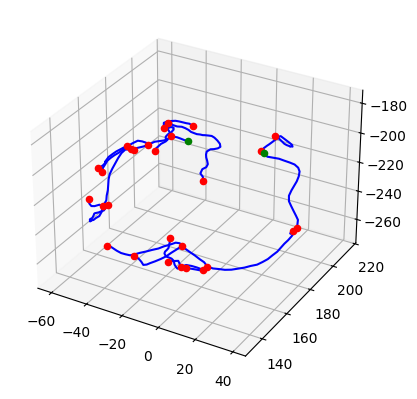

In [230]:
# let's visualize the roots
# Plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for node in ground_truth_json_graph["nodes"]:
    [x, y, z] = node["pos"]
    is_root = node.get("is_root", False)
    if is_root:
        ax.scatter(x, y, z, c="g")
    else:
        ax.scatter(x, y, z, c="r")

for edge in ground_truth_json_graph["edges"]:
    skeletons = edge["skeletons"]
    xs, ys, zs = zip(*skeletons) # this is all we plot
    ax.plot(xs, ys, zs, c="b")

# get the np array from the plot
plt.show()

In [231]:
print(ground_truth_json_graph["edges"])

[{'length': 45.555038631672225, 'skeletons': [[-3.9306640625, 149.6103515625, -255.54998779296875], [-6.126192249041056, 149.9599770429464, -258.04998779296875], [-8.14768095468244, 151.59885282968244, -259.00876075463884], [-10.283266892278974, 153.416079392279, -259.6384502387676], [-12.042070778520191, 155.4932426535202, -260.30305196216773], [-13.879228167310293, 157.270957967176, -261.04998779296875], [-15.881907363569796, 158.8194203219174, -262.0133105071458], [-18.09720079118183, 159.92551012955806, -263.04998779296875], [-20.317997051971894, 160.76020554989023, -263.7871488071087], [-21.973209699622256, 162.24078782462226, -264.54998779296875], [-23.522207272858633, 163.79071705338518, -265.2775211090338], [-24.75324306631261, 165.97589931631262, -266.25293395846586], [-25.2983951599041, 168.3346619744244, -266.95749371599106], [-26.055853887869763, 170.46838091556629, -267.79875218127955], [-27.393614739047827, 172.75494286404782, -268.04998779296875], [-28.7363687369718, 175

In [232]:
# Let's find the nodes with the largest bifurcations

# we only have nodes and edges. We need to count the number of times
# a node appears in the edges. This is the number of bifurcations

nodes = ground_truth_json_graph["nodes"]
edges = ground_truth_json_graph["edges"]

node_ids = [node["id"] for node in nodes]

bifurcation_counter = {node_id: 0 for node_id in node_ids}

for edge in edges:
    target = edge["target"]
    source = edge["source"]

    bifurcation_counter[target] += 1
    bifurcation_counter[source] += 1

print(bifurcation_counter)

# let's get the two nodes with the max bifurcations
sorted_bifurcations = sorted(bifurcation_counter.items(), key=lambda x: x[1], reverse=True)
print(sorted_bifurcations)

{1: 3, 2: 3, 4: 3, 5: 3, 7: 3, 8: 3, 9: 3, 10: 3, 11: 3, 12: 3, 13: 3, 14: 3, 15: 3, 18: 1, 19: 1, 20: 1, 21: 1, 23: 1, 25: 1, 27: 1, 28: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1, 37: 1, 38: 1, 39: 1}
[(1, 3), (2, 3), (4, 3), (5, 3), (7, 3), (8, 3), (9, 3), (10, 3), (11, 3), (12, 3), (13, 3), (14, 3), (15, 3), (18, 1), (19, 1), (20, 1), (21, 1), (23, 1), (25, 1), (27, 1), (28, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (37, 1), (38, 1), (39, 1)]


Alright Bifurcation analysis is useless.

Next try would be to find the segmentation arteries that are the biggest.

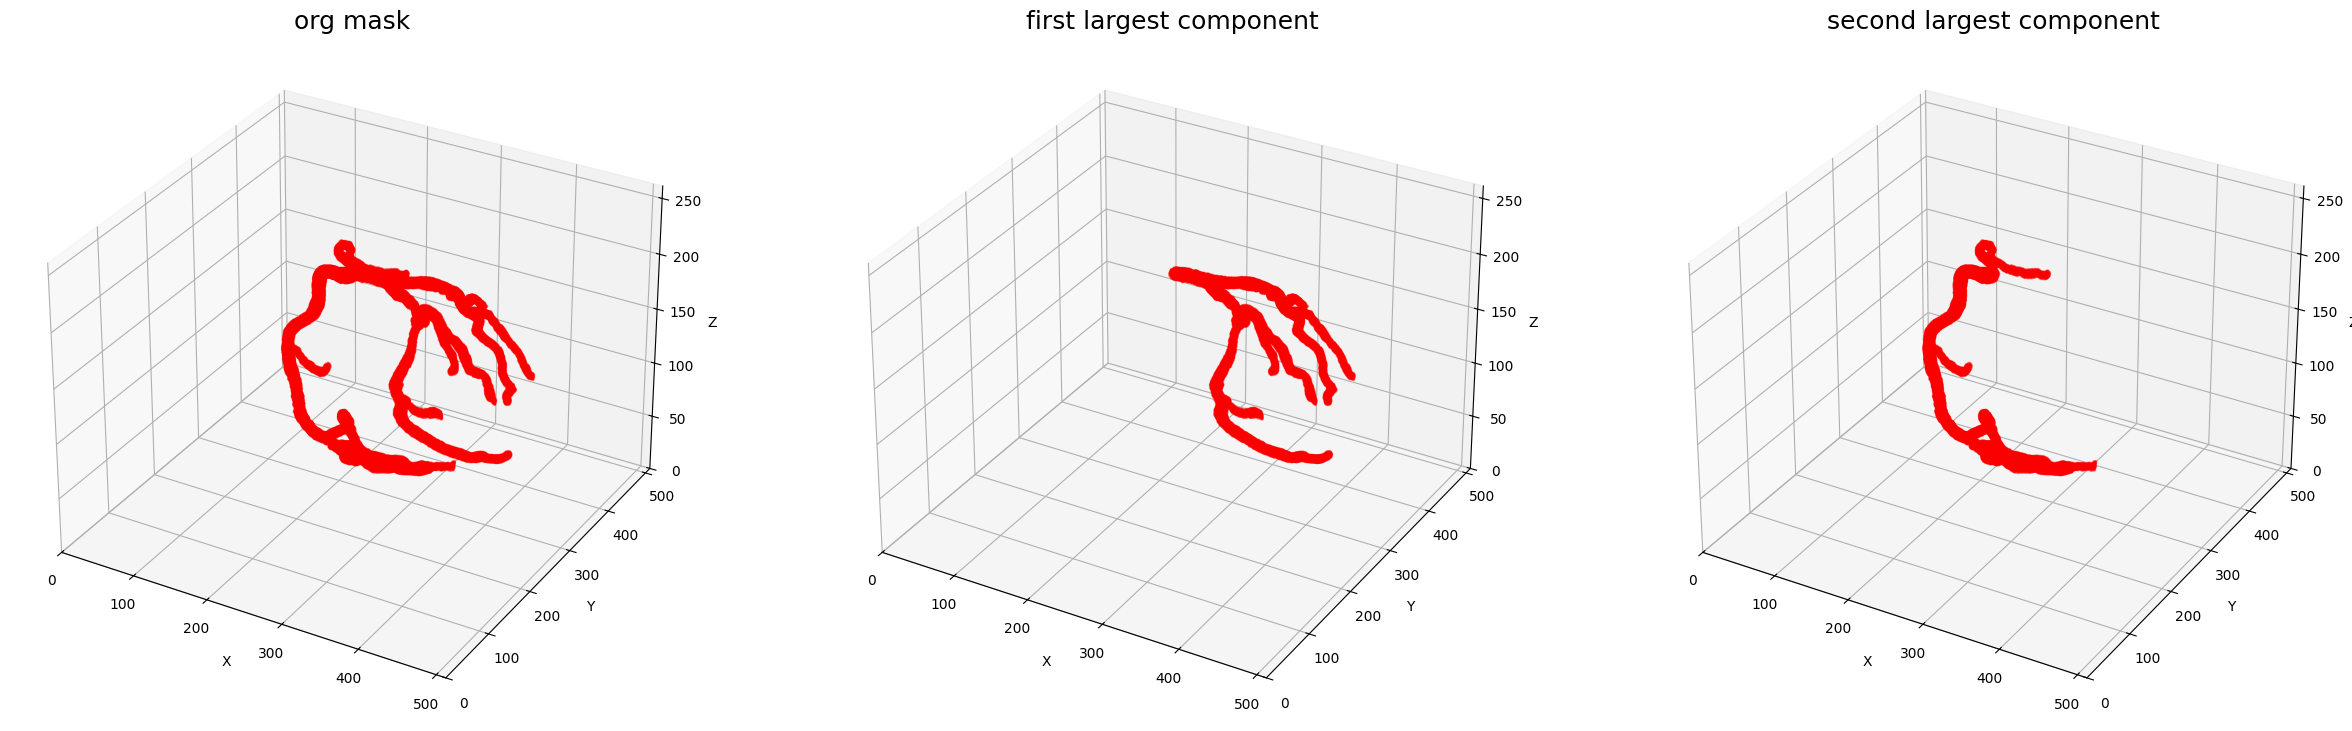

In [233]:
# Let's start with the mask
mask = nib.load(label_fp)
mask_matrice = mask.get_fdata()

# let's get the two biggest components, because we need two points
from skimage.measure import label, regionprops

# Label connected components
labeled_array, num_features = label(mask_matrice, return_num=True)

# Use a histogram to efficiently calculate the sizes of each labeled component
component_sizes = np.bincount(labeled_array.ravel())

# Exclude the background component (label 0)
component_sizes[0] = 0

# Get the two largest component labels
largest_labels = np.argsort(component_sizes)
largest_labels = largest_labels[-2:]

# this should include the left and right coronary artery.
# let's create a mask with both and compare it with the original mask

# Create a mask for each component
largest_mask_0 = np.isin(labeled_array, largest_labels[0])
largest_mask_1 = np.isin(labeled_array, largest_labels[1])

# Plot the masks
matrices = [mask_matrice, largest_mask_0, largest_mask_1]
titles = ["org mask", "first largest component", "second largest component"]

visualize_3d_matrices(matrices, titles)

In [234]:
# let's write a function, that finds the point(s) with the largest diameter.

from scipy.ndimage import distance_transform_edt

# the segmentation has only one conncected component
def find_largest_points(segmentation):
    print("please make sure that you're only passing a single coronary artery.")

    distance_transform_3d = distance_transform_edt(segmentation)
    # Find the maximum distance
    max_idx = np.unravel_index(np.argmax(distance_transform_3d), distance_transform_3d.shape)

    print(f"Thickest point center: {max_idx}")

    return max_idx

max_idx_largest_mask_0 = find_largest_points(largest_mask_0)


please make sure that you're only passing a single coronary artery.
Thickest point center: (348, 191, 141)


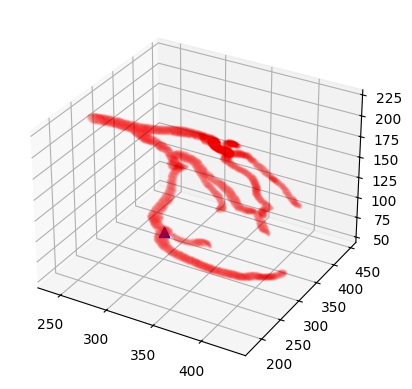

In [235]:
# let's plot this point on the mask

def plot_masks_with_points(mask, points_of_interest):
    fig = plt.figure()

    ax = fig.add_subplot(111, projection='3d')
    x, y, z = np.where(mask == 1)

    ax.scatter(x, y, z, c='red', marker='o', s=0.005, alpha=0.2)
    
    for point in points_of_interest:
        x, y, z = point
        ax.scatter(x, y, z, c='blue', marker='^', s=50, alpha=1.0)

    plt.show()

plot_masks_with_points(mask=largest_mask_0, points_of_interest=[max_idx_largest_mask_0])

(348, 191, 141)
[185. 349. 174.]


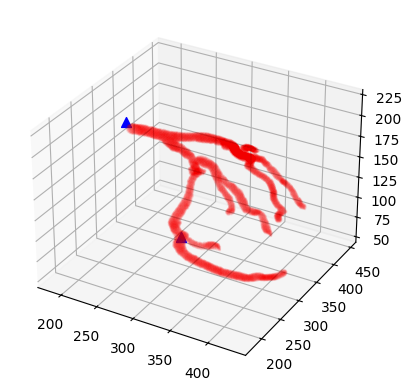

In [236]:
# okay cool, let's check where the ground truth root node is
root_node = roots[0]
root_node_pos = root_node["pos"]
root_node_pos = np.array(root_node_pos + [1])

def RAS_to_voxel(point: np.array):
    # affine transformation
    point = np.linalg.inv(mask.affine) @ point
    point = point[:3]

    return point

root_node_pos_voxel = RAS_to_voxel(root_node_pos)

print(max_idx_largest_mask_0)
print(root_node_pos_voxel)

plot_masks_with_points(mask=largest_mask_0, points_of_interest=[max_idx_largest_mask_0, root_node_pos_voxel])


In [237]:
# alright that wasn't it. However we see that it didn't choose an "edge point". I think we can specify it to find a point that is close to an edge and it should work.

# step 1: get all edge points from the graph
def get_endpoints_in_graph(json_graph):
    endpoints = []

    nodes = json_graph["nodes"]
    # we need to sort the nodes by ids
    nodes = sorted(nodes, key=lambda x: x["id"])
    edges = json_graph["edges"]

    node_ids = [node["id"] for node in nodes]
    # we count how many times a node appears in edges.
    # if it appears only once, it's an endpoint
    bifurcation_counter = {node_id: 0 for node_id in node_ids}

    for edge in edges:
        target = edge["target"]
        source = edge["source"]

        bifurcation_counter[target] += 1
        bifurcation_counter[source] += 1
    
    # let's sort it with lowest values first
    bifurcation_counter = {k: v for k, v in sorted(bifurcation_counter.items(), key=lambda item: item[1])}
    print(bifurcation_counter)
    for node_id, count in bifurcation_counter.items():
        if count > 1:
            break

        if count == 1:
            for node in nodes:
                if node.get("id") == node_id:
                    endpoints.append(node["pos"])

    return endpoints

endpoints = get_endpoints_in_graph(ground_truth_json_graph)
print(endpoints)

{18: 1, 19: 1, 20: 1, 21: 1, 23: 1, 25: 1, 27: 1, 28: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1, 37: 1, 38: 1, 39: 1, 1: 3, 2: 3, 4: 3, 5: 3, 7: 3, 8: 3, 9: 3, 10: 3, 11: 3, 12: 3, 13: 3, 14: 3, 15: 3}
[[-56.7783203125, 161.7080078125, -219.04998779296875], [-11.8896484375, 150.5654296875, -256.04998779296875], [-31.6279296875, 179.5361328125, -270.04998779296875], [-54.2314453125, 198.9560546875, -231.04998779296875], [-47.5458984375, 140.3779296875, -218.54998779296875], [14.5341796875, 186.2216796875, -198.04998779296875], [-32.9013671875, 199.5927734375, -206.54998779296875], [-30.6728515625, 151.8388671875, -188.54998779296875], [-4.2490234375, 153.7490234375, -260.04998779296875], [-48.1826171875, 148.3369140625, -204.04998779296875], [5.9384765625, 210.7353515625, -208.54998779296875], [30.1337890625, 190.0419921875, -250.04998779296875], [-26.8525390625, 145.4716796875, -253.54998779296875], [-37.0400390625, 214.2373046875, -257.04998779296875], [-60.5986328125, 170.303710937

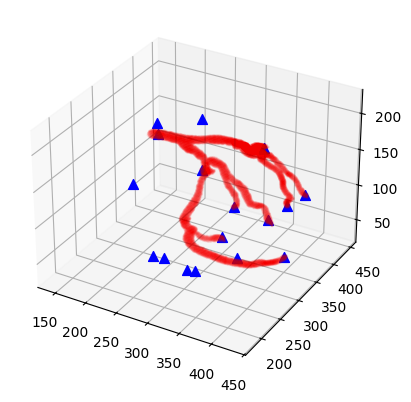

In [238]:
# lets plot those endpoints
# 1. let's conver the coordinate system for each point
endpoints_voxel = [RAS_to_voxel(np.array(endpoint + [1])) for endpoint in endpoints]

plot_masks_with_points(mask=largest_mask_0, points_of_interest=endpoints_voxel)

In [239]:
print(len(endpoints_voxel))

17
